# An Earth the animation can be right about, and a vehicle that comes apart

Everything drawn here comes from measured data or from an integration. Nothing
in this notebook draws a trajectory, chooses a colour for a mountain, or places
a spent stage by hand.

Four archives and one integrator:

| what | source | resolution |
| --- | --- | --- |
| the body | WGS84 reference ellipsoid | defining constants |
| imagery | Blue Marble Next Generation GeoTIFFs, by month | 86400 x 43200, 15 arc-seconds |
| elevation | GMTED2010 mean-elevation tiles | 7.5 arc-seconds |
| the vehicle | `sarmat_mass_model` stations against the mould line | as flown |
| the spent stages | `propagate_jettison`, J2 gravity and their own drag | integrated |

## What changed, and what it was worth

The renderer used to intersect a **sphere** and sample a 4096 x 2048 JPEG. Both
were replaced, and the two changes are worth very different amounts:

* **The ellipsoid is worth 21 km.** Not because the Earth's polar flattening is
  21 km — that is a *radius* difference, under two pixels on a full-disc globe —
  but because treating geodetic latitude as geocentric moves a surface point at
  45 degrees **tangentially** by 21,385 m. An impact marker 21 km from the
  trajectory that produced it is the disagreement between picture and physics
  this whole layer exists to stop.

  The two numbers come out equal below, and that is not a coincidence: the
  geodetic-geocentric difference peaks at `f` radians at 45 degrees, so the
  displacement is `r * f`, which is `a - b` to first order. They are the same
  quantity pointing in different directions, and only one of them is visible.
* **The imagery is worth a factor of 2,500 in pixels**, and it only shows where
  the camera is close enough to ask for it — which is exactly where the
  attention pacing spends its frames.
* **The relief shading is worth about 5 % of brightness.** That is measured
  below and it is deliberately not oversold: BMNG is surface reflectance and
  already carries the mountains through their snow and vegetation, so lighting
  the slopes is a refinement rather than a transformation.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from passes.viz import (
    WGS84, Camera, ChaseRig, SimulationHistory, TrajectoryAnimator,
    default_blue_marble, default_terrain, render,
)
from passes.viz.ellipsoid import ecef_to_geodetic, geodetic_to_ecef, local_vertical

BLUE_MARBLE = default_blue_marble()
TERRAIN = default_terrain()
print(f"Blue Marble months available: {BLUE_MARBLE.months}")
print(f"GMTED2010 tiles: {TERRAIN.n_tiles}, coverage {TERRAIN.coverage} degrees")

Blue Marble months available: (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)
GMTED2010 tiles: 108, coverage (-90.0, 90.0) degrees


## 1. The ellipsoid, measured

The number that justifies the change. A surface point at 45 degrees geodetic
latitude, against the same latitude read as geocentric.

In [2]:
true_point = geodetic_to_ecef(np.deg2rad(45.0), 0.0, 0.0, WGS84)
radius = float(np.linalg.norm(true_point))
as_geocentric = radius * np.array([np.cos(np.deg2rad(45.0)), 0.0, np.sin(np.deg2rad(45.0))])
print(f"geodetic vs geocentric at 45 deg: {np.linalg.norm(true_point - as_geocentric):,.0f} m")
print(f"polar flattening for comparison:  {WGS84.semi_major - WGS84.semi_minor:,.0f} m")

# And the local vertical, which is what a camera's "up" and every shading
# normal needs, is not the position direction.
normal = local_vertical(np.deg2rad(45.0), 0.0)
angle = np.rad2deg(np.arccos(float(normal @ (true_point / radius))))
print(f"local vertical is {angle:.4f} deg off radial at 45 deg latitude")

geodetic vs geocentric at 45 deg: 21,385 m
polar flattening for comparison:  21,385 m
local vertical is 0.1924 deg off radial at 45 deg latitude


## 2. Elevation, against published heights

The archive is 26 GB for the mean-elevation product alone, so nothing is loaded
globally: `Terrain.elevation` groups query points by tile and issues **one
windowed read per tile**.

In [3]:
sites = [
    ("Dead Sea shore", 31.5, 35.5, -412.0),
    ("Denver", 39.74, -104.99, 1605.0),
    ("Everest summit", 27.9881, 86.9250, 8848.0),
    ("Dombarovskiy pad", 51.09, 59.84, None),
    ("open Pacific", 0.0, -140.0, 0.0),
]
for name, lat, lon, published in sites:
    sample = TERRAIN.elevation(lat, lon)
    height = float(sample.elevation)
    note = "" if published is None else f"  (published {published:,.0f} m, "                                        f"error {height - published:+,.0f} m)"
    print(f"{name:18s} {height:8,.0f} m{note}")
print()
print("Everest comes back 180 m low and no statistic recovers it: a 7.5 arc-second")
print("cell is 230 m across and a summit narrower than its cell does not survive")
print("averaging. Cell size is the limit, not the choice of product.")

Dead Sea shore         -412 m  (published -412 m, error +0 m)
Denver                1,605 m  (published 1,605 m, error +0 m)
Everest summit        8,665 m  (published 8,848 m, error -183 m)
Dombarovskiy pad        348 m
open Pacific              0 m  (published 0 m, error +0 m)

Everest comes back 180 m low and no statistic recovers it: a 7.5 arc-second
cell is 230 m across and a summit narrower than its cell does not survive
averaging. Cell size is the limit, not the choice of product.


## 3. Relief shading — and why the key light is not overhead

Shading works on the cosine between the light and a slope-perturbed normal. A
light along the **local vertical** therefore meets terrain slope at second
order and does essentially nothing. This is measured rather than argued, and it
is why `TrajectoryAnimator(lighting="track")` now tilts its key light 55 degrees
above the local horizon instead of pointing it straight up.

In [4]:
relief = TERRAIN.relief()
texture = BLUE_MARBLE.texture(height=4096, month=6)
latitude, longitude = 28.0, 86.9  # the Himalayan front

point = geodetic_to_ecef(np.deg2rad(latitude), np.deg2rad(longitude), 0.0, WGS84)
up = local_vertical(np.deg2rad(latitude), np.deg2rad(longitude))
east = np.array([-np.sin(np.deg2rad(longitude)), np.cos(np.deg2rad(longitude)), 0.0])
camera = Camera(position=point + 700e3 * up, target=point, up=np.array([0.0, 0.0, 1.0]),
                fov=np.deg2rad(40.0), width=700, height=700)

print(f"{'key light':>12}  {'peak change':>12}  {'rms':>8}  {'ground brightness':>18}")
for elevation_deg in (90.0, 70.0, 55.0, 40.0):
    angle = np.deg2rad(elevation_deg)
    sun = np.sin(angle) * up + np.cos(angle) * east
    smooth, _ = render(camera, texture, WGS84, sun=sun, atmosphere=0.0, specular=0.0)
    shaded, _ = render(camera, texture, WGS84, sun=sun, relief=relief,
                       atmosphere=0.0, specular=0.0)
    difference = shaded - smooth
    print(f"{elevation_deg:9.0f} deg  {np.abs(difference).max():12.4f}  "
          f"{np.sqrt((difference ** 2).mean()):8.4f}  {shaded.mean():18.3f}")

   key light   peak change       rms   ground brightness


       90 deg        0.0051    0.0003               0.320


       70 deg        0.0235    0.0019               0.307


       55 deg        0.0370    0.0033               0.280


       40 deg        0.0506    0.0046               0.240


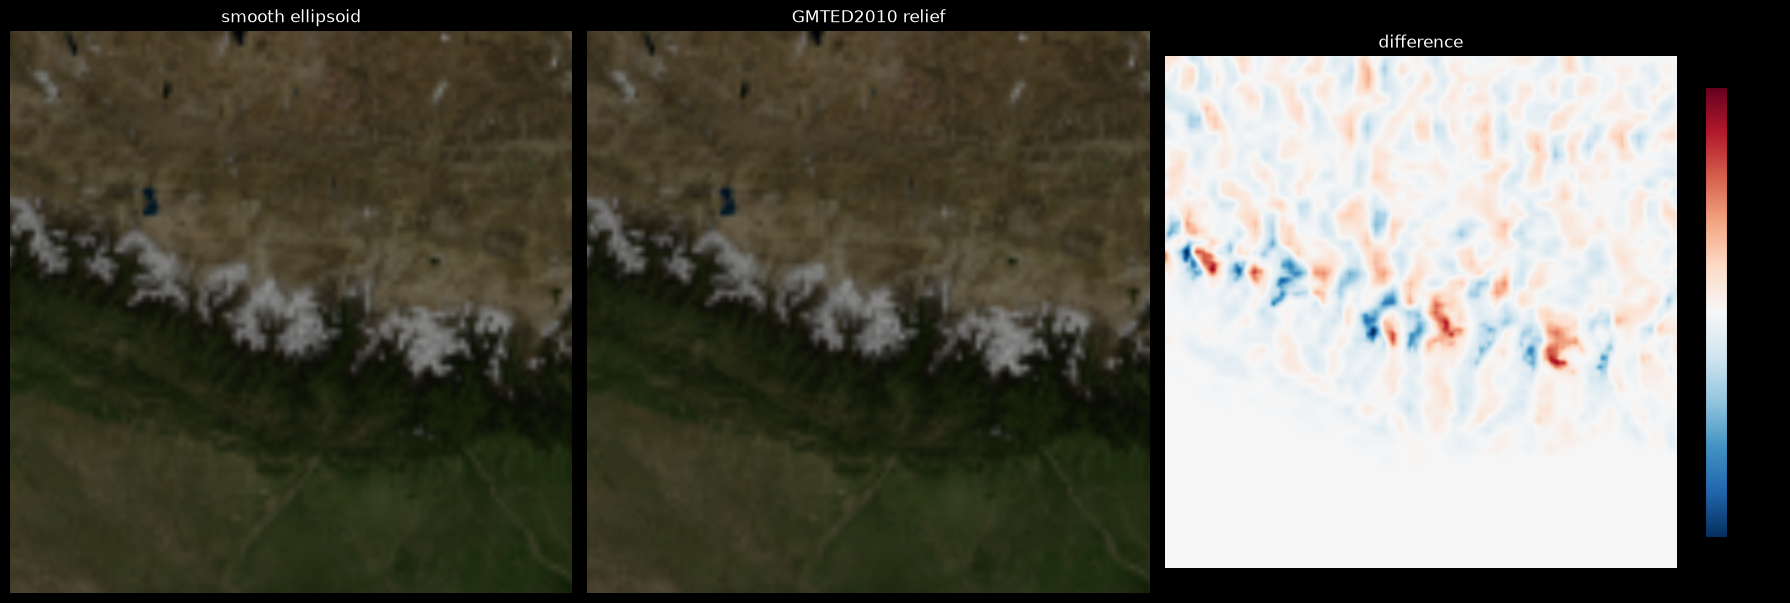

The ridges light on their sun-facing side and darken on the other; the
Gangetic plain south of the front is exactly zero, because flat ground has
no slope. That is the check that this is data and not a texture.


In [5]:
angle = np.deg2rad(25.0)
sun = np.sin(angle) * up + np.cos(angle) * east
smooth, _ = render(camera, texture, WGS84, sun=sun, atmosphere=0.0, specular=0.0, ambient=0.15)
shaded, _ = render(camera, texture, WGS84, sun=sun, relief=relief, atmosphere=0.0,
                   specular=0.0, ambient=0.15)
difference = (shaded - smooth)[..., 0]

figure, axes = plt.subplots(1, 3, figsize=(18, 6.2), facecolor="black")
axes[0].imshow(np.clip(smooth, 0.0, 1.0)); axes[0].set_title("smooth ellipsoid", color="white")
axes[1].imshow(np.clip(shaded, 0.0, 1.0)); axes[1].set_title("GMTED2010 relief", color="white")
image = axes[2].imshow(difference, cmap="RdBu_r", vmin=-0.06, vmax=0.06)
axes[2].set_title("difference", color="white")
for ax in axes:
    ax.axis("off")
figure.colorbar(image, ax=axes[2], fraction=0.04)
figure.tight_layout()
plt.show()

print("The ridges light on their sun-facing side and darken on the other; the")
print("Gangetic plain south of the front is exactly zero, because flat ground has")
print("no slope. That is the check that this is data and not a texture.")

## 4. Displacement, against the elevation it is supposed to reproduce

Relief shading changes how a pixel is *lit*. Displacement changes where the
ground *is* — the ray is marched onto the terrain instead of onto the reference
ellipsoid. Looking straight down, the distance to the ground must shorten by
exactly the elevation beneath the ray, so the depth buffer can be compared
against `Terrain.elevation` rather than against a picture.

In [6]:
height = 60.0e3
overhead = Camera(position=point + height * up, target=point,
                  up=np.array([0.0, 0.0, 1.0]), fov=np.deg2rad(30.0),
                  width=200, height=200)
_, on_ellipsoid = render(overhead, texture, WGS84, sun=up, relief=relief,
                         atmosphere=0.0, specular=0.0)
_, on_terrain = render(overhead, texture, WGS84, sun=up, relief=relief, displace=True,
                       atmosphere=0.0, specular=0.0)
centre = (overhead.height // 2, overhead.width // 2)
lifted = float(on_ellipsoid[centre] - on_terrain[centre])

rows, cols = relief.shape
row = int((90.0 - latitude) / (180.0 / rows))
column = int((longitude + 180.0) / (360.0 / cols))
print(f"ray shortened by      {lifted:8,.0f} m")
print(f"relief grid there     {float(relief.elevation[row, column]):8,.0f} m")
print(f"7.5 arc-second archive {float(TERRAIN.elevation(latitude, longitude).elevation):7,.0f} m")
print()
print("The march reproduces the grid it reads, not the archive: a 9.8 km cell")
print("does not carry a summit. It also does not silhouette — a peak is lit and")
print("lifted, but it casts no hard edge over the valley behind it.")

ray shortened by         6,129 m
relief grid there        6,064 m
7.5 arc-second archive   7,005 m

The march reproduces the grid it reads, not the archive: a 9.8 km cell
does not carry a summit. It also does not silhouette — a peak is lit and
lifted, but it casts no hard edge over the valley behind it.


## 5. Native-resolution imagery, where the camera can see it

The global mosaic is decimated. At a 20 km stand-off it shows about one texel
per forty pixels, so a close-up needs the source. `BlueMarble.window` reads the
GeoTIFFs directly, assembling across tile edges on a shared decimation stride —
the tile grid breaks at the equator and every 90 degrees, so "a close-up never
straddles an edge" is not true of anything launched from or aimed at a low
latitude.

mosaic  4096 x 8192,    4,892 m/pixel
crop    241 x 241,      291 m/pixel  over 50.587..51.592 N, 59.338..60.342 E


local contrast: mosaic 0.00010, with crop 0.00062


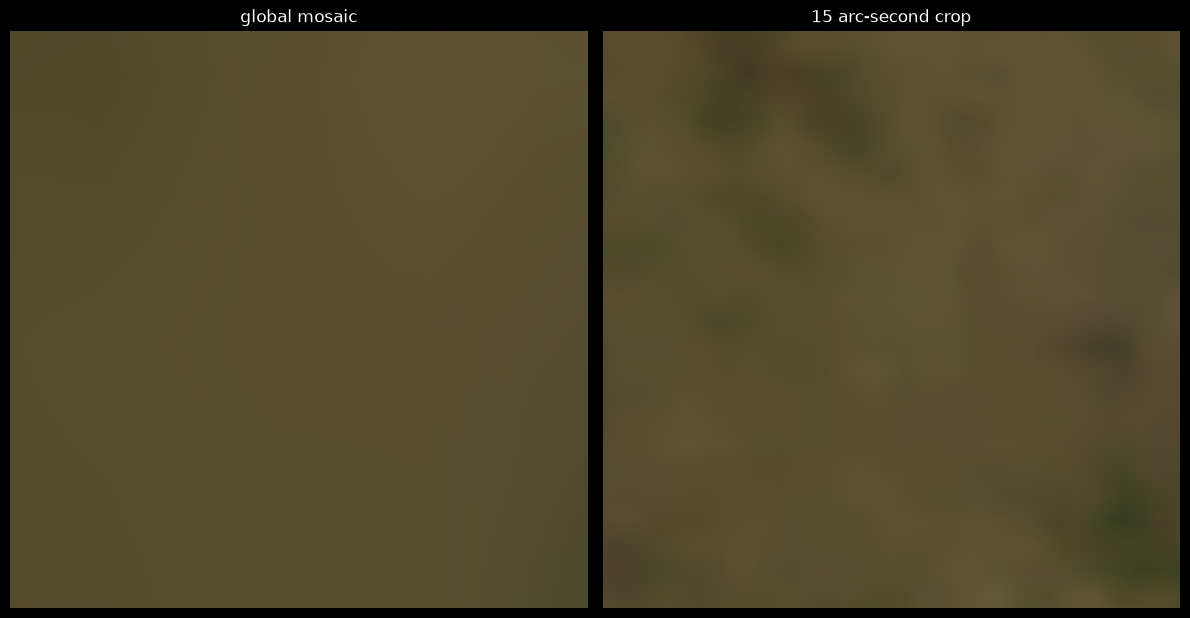

In [7]:
pad_lat, pad_lon = 51.09, 59.84
crop = BLUE_MARBLE.window((pad_lat - 0.5, pad_lat + 0.5), (pad_lon - 0.5, pad_lon + 0.5),
                          month=6, max_width=1024)
mosaic = BLUE_MARBLE.texture(height=4096, month=6)
print(f"mosaic  {mosaic.shape[0]} x {mosaic.shape[1]}, {mosaic.ground_resolution:8,.0f} m/pixel")
print(f"crop    {crop.shape[0]} x {crop.shape[1]}, {crop.ground_resolution:8,.0f} m/pixel"
      f"  over {crop.south:.3f}..{crop.north:.3f} N, {crop.west:.3f}..{crop.east:.3f} E")

pad = geodetic_to_ecef(np.deg2rad(pad_lat), np.deg2rad(pad_lon), 0.0, WGS84)
pad_up = local_vertical(np.deg2rad(pad_lat), np.deg2rad(pad_lon))
close = Camera(position=pad + 20e3 * pad_up, target=pad, up=np.array([0.0, 0.0, 1.0]),
               fov=np.deg2rad(30.0), width=600, height=600)
coarse, _ = render(close, mosaic, WGS84, sun=pad_up, atmosphere=0.0, specular=0.0)
fine, _ = render(close, [mosaic, crop], WGS84, sun=pad_up, atmosphere=0.0, specular=0.0)

def local_contrast(image):
    return float(np.std(np.diff(image[..., 0], axis=1)))

print(f"local contrast: mosaic {local_contrast(coarse):.5f}, "
      f"with crop {local_contrast(fine):.5f}")

figure, axes = plt.subplots(1, 2, figsize=(12, 6.2), facecolor="black")
axes[0].imshow(np.clip(coarse, 0.0, 1.0)); axes[0].set_title("global mosaic", color="white")
axes[1].imshow(np.clip(fine, 0.0, 1.0)); axes[1].set_title("15 arc-second crop", color="white")
for ax in axes:
    ax.axis("off")
figure.tight_layout()
plt.show()

## 6. A staged launch, flown

Four legs through `fly_mission`: a gravity-turn first stage, a coast across
separation, a prograde second stage, and a ballistic fall terminated at the
ground. Every state below came out of the integrator's right-hand side.

In [8]:
from passes.flight.mission import MissionSegment, fly_mission
from passes.flight.propulsion import Burn
from passes.flight.simulator import FlightConfiguration, FlightSimulator
from passes.systems.mass import sarmat_mass_model
from passes.viz.staging import StagingPlan, jettison_histories

simulator = FlightSimulator(FlightConfiguration())
launch_lat, launch_lon = np.deg2rad(51.09), np.deg2rad(59.84)
pad_point = geodetic_to_ecef(launch_lat, launch_lon, 0.0, WGS84)
pad_normal = local_vertical(launch_lat, launch_lon)
east_axis = np.array([-np.sin(launch_lon), np.cos(launch_lon), 0.0])
plane = np.cross(pad_normal, east_axis)
plane /= np.linalg.norm(plane)

started = time.perf_counter()
flown = fly_mission(
    simulator,
    simulator.state_at(pad_point, np.zeros(3), mass=208.1e3),
    [
        MissionSegment(110.0, Burn(110.0, 4.6e6, 3050.0, "gravity_turn", plane,
                                   kick_angle=0.10, label="stage 1"), "boost"),
        MissionSegment(20.0, None, "staging coast", "first stage falls away"),
        MissionSegment(120.0, Burn(120.0, 1.0e6, 3200.0, "prograde", label="stage 2"),
                       "insertion"),
        MissionSegment(900.0, None, "ballistic coast", "", stop_at_ground=True),
    ],
    samples_per_segment=90, method="LSODA", rtol=1e-8,
)
print(f"flown in {time.perf_counter() - started:.1f} s, "
      f"{flown.flight_time:,.0f} s of flight")
for event in flown.events:
    print(f"  T+{event.time:6.1f} s  {event.name:20s} {event.detail}")

flown in 2.3 s, 1,150 s of flight
  T+   0.0 s  lift-off             boost
  T+ 110.0 s  stage 1 cutoff       70 km, 2,799 m/s, gamma +78.7 deg
  T+ 130.0 s  stage 2 ignition     123 km, 2,612 m/s, gamma +78.0 deg
  T+ 250.0 s  stage 2 cutoff       636 km, 8,604 m/s, gamma +75.4 deg
  T+1150.0 s  end of mission       6,207 km, 4,874 m/s, gamma +75.6 deg


In [9]:
base = SimulationHistory.from_flight_result(flown.result, "two-stage launch")
history = SimulationHistory(
    label=base.label, times=base.times, positions=base.positions,
    velocities=base.velocities, quaternions=base.quaternions, extras=base.extras,
    phases=flown.phases, events=flown.events,
)

# The mould line the mass model was built from, so the glyph and the mass
# properties describe the same vehicle.
stations = np.linspace(0.0, 35.4, 400)
radii = np.where(stations < 3.3, 1.5 * (stations / 3.3) ** 0.59, 1.5)
mass_model = sarmat_mass_model(stations, radii)

plan = StagingPlan.from_events(
    mass_model, flown.events,
    {"stage1": "stage 1 cutoff", "stage2": "stage 2 cutoff"},
)
for phase in plan.phases():
    end = "end" if not np.isfinite(phase.end_time) else f"{phase.end_time:6.0f} s"
    print(f"T+{phase.start_time:6.1f} s to {end:>8s}   {phase.name}")

T+   0.0 s to    110 s   payload + bus + stage2 + stage1
T+ 110.0 s to    250 s   payload + bus + stage2
T+ 250.0 s to      end   payload + bus


### Where the spent stages went

Integrated, not drawn. Each leaves with the stack's state at separation plus a
1.5 m/s push-off, and is then propagated under the same J2 gravity the flight
used and **its own** drag — an empty stage is light and blunt where the stack
was heavy and slender, so it decelerates harder and falls behind. The push-off
is the one number here with no source in this framework, and the divergence
below shows how little of the answer it sets.

In [10]:
frontal = np.pi * 1.5 ** 2
spent = jettison_histories(history, plan, {"stage1": frontal, "stage2": frontal})
for name, run in spent.items():
    end = float(run.times[-1])
    altitude = float(ecef_to_geodetic(run.positions[-1], WGS84)[2])
    gap = float(np.linalg.norm(run.positions[-1] - history.sample(end)["position"]))
    print(f"{name}: separated T+{run.times[0]:5.0f} s, tracked to T+{end:5.0f} s, "
          f"final altitude {altitude / 1e3:8.1f} km, {gap / 1e3:8.1f} km from the vehicle")
print()
print("The first stage comes down and the propagation stops at the surface — the")
print("same terminal condition fly_mission uses, and for the same reason: without")
print("it a spent booster carries on underground. The second stage separates above")
print("the atmosphere and stays nearly co-orbital, which is also what it should do.")

stage1: separated T+  110 s, tracked to T+  774 s, final altitude     12.8 km,   4284.0 km from the vehicle
stage2: separated T+  250 s, tracked to T+ 1150 s, final altitude   6217.9 km,      1.5 km from the vehicle

The first stage comes down and the propagation stops at the surface — the
same terminal condition fly_mission uses, and for the same reason: without
it a spent booster carries on underground. The second stage separates above
the atmosphere and stays nearly co-orbital, which is also what it should do.


In [11]:
animator = TrajectoryAnimator(
    history,
    surface=WGS84,
    month=6,
    staging=plan,
    mould_line=(stations, radii),
    jettisoned=spent,
    rig=ChaseRig(back_scale=2.0, back_offset=40e3),
    width=1280, height=720,
)
for when in (5.0, 60.0, 115.0, 300.0, history.times[-1]):
    frame = animator.frame_at(when)
    textures, displacing = animator._imagery_for(frame.camera)
    plt.close(frame.axes.figure)
    print(f"T+{when:7.1f} s  eye {animator.camera_altitude(frame.camera) / 1e3:8.1f} km  "
          f"{len(textures)} texture(s)  displace={displacing!s:5s}  "
          f"stack: {' + '.join(plan.present_at(when))}")

T+    5.0 s  eye     10.5 km  2 texture(s)  displace=True   stack: payload + bus + stage2 + stage1


T+   60.0 s  eye     33.9 km  2 texture(s)  displace=True   stack: payload + bus + stage2 + stage1


T+  115.0 s  eye    144.6 km  1 texture(s)  displace=True   stack: payload + bus + stage2


T+  300.0 s  eye   1637.8 km  1 texture(s)  displace=False  stack: payload + bus


T+ 1150.0 s  eye  10381.7 km  1 texture(s)  displace=False  stack: payload + bus


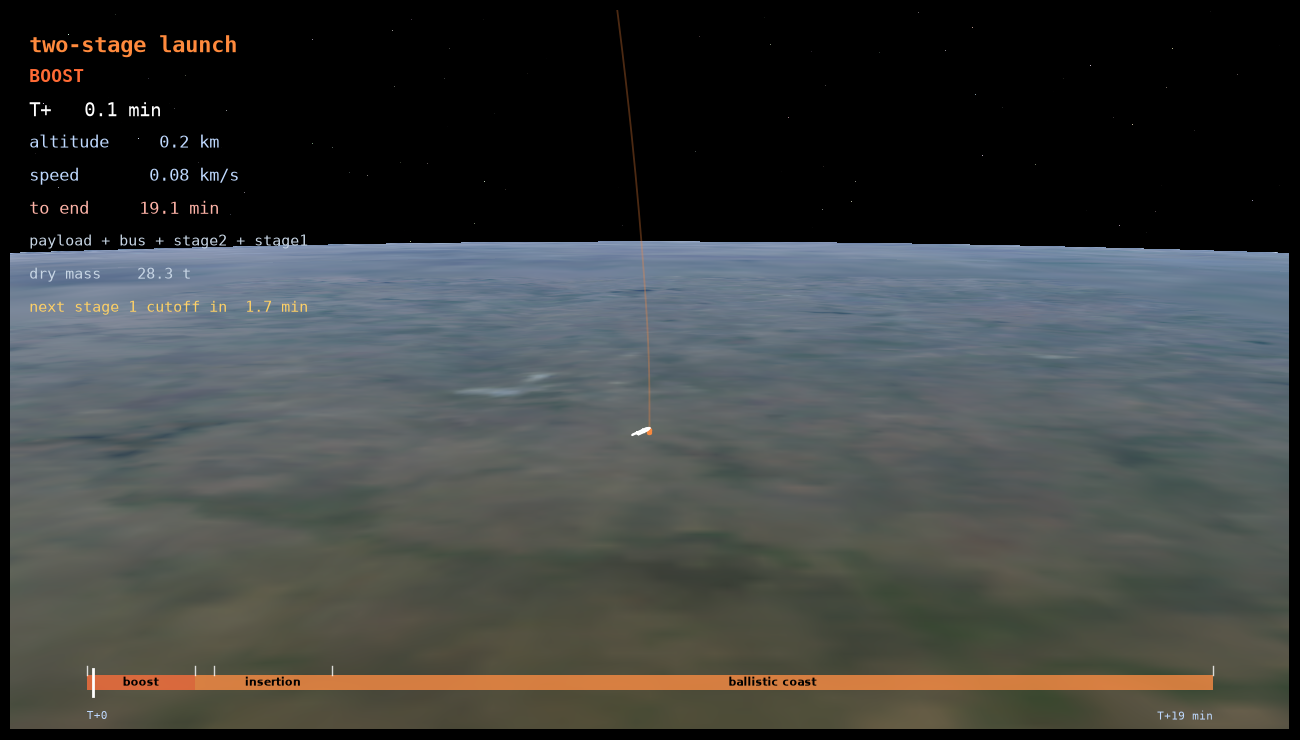

Lift-off: four elements on the stack, native-resolution Blue Marble over
the pad, and the ray marched onto GMTED2010 terrain rather than onto a
smooth datum.


In [12]:
figure, frame = animator.figure_at(6.0)
plt.show()
print("Lift-off: four elements on the stack, native-resolution Blue Marble over")
print("the pad, and the ray marched onto GMTED2010 terrain rather than onto a")
print("smooth datum.")

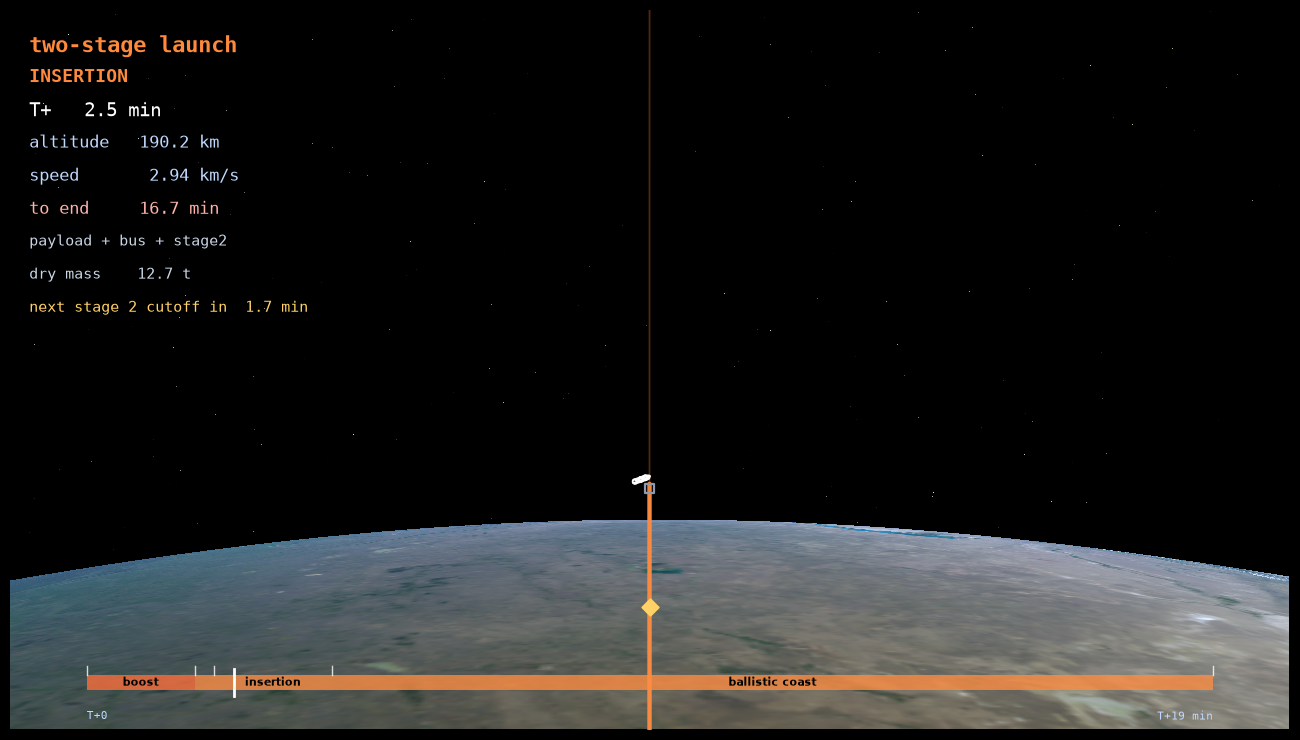

Past first-stage separation: three elements, and the spent booster on its
own integrated arc behind.


In [13]:
figure, frame = animator.figure_at(150.0)
plt.show()
print("Past first-stage separation: three elements, and the spent booster on its")
print("own integrated arc behind.")

In [14]:
started = time.perf_counter()
path = animator.render_sequence("staged_launch.mp4", seconds=20.0, fps=24)
print(f"{path}  {path.stat().st_size / 1e6:.2f} MB in "
      f"{time.perf_counter() - started:.0f} s")
print()
print("Attention pacing decides the frame times, so the ascent and the terminal")
print("minute get the screen time and the coast does not.")

staged_launch.mp4  1.59 MB in 361 s

Attention pacing decides the frame times, so the ascent and the terminal
minute get the screen time and the coast does not.


## What is still not claimed

* **Displacement does not silhouette.** The march advances each ray to where
  its own altitude equals the terrain under it. There is no occlusion test, so
  a ridge does not cast a hard edge over the valley behind it, and at grazing
  incidence — where that would matter most — the iteration is least well
  conditioned and the result falls back to the reference ellipsoid.
* **The relief grid resolves ranges, not peaks.** At 2048 rows a cell is 9.8 km.
  The Himalayan front and the Andean scarp read correctly; a single ridge does
  not exist at that scale and no exaggeration factor invents it.
* **The separation push-off is a parameter, not a measurement.** The mass model
  has no separation hardware in it. Everything else about a discarded stage's
  trajectory is integrated.
* **The trajectories are still spherical where the physics is.**
  `FlightSimulator` integrates J2 gravity about the WGS84 semi-major axis but
  measures altitude as radius minus that constant. Drawing those states on the
  ellipsoid is right for *position*, which is a genuine Cartesian vector; the
  altitude the simulator's own drag model saw is still a spherical one.